In [1]:
# Importar el dataset
from google.colab import files
uploaded = files.upload()

Saving Womens Clothing E-Commerce Reviews.csv to Womens Clothing E-Commerce Reviews.csv


In [2]:
# convertir el dataset a pandas
import pandas as pd
df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")

# Ver 5 primeras filas
df.head()


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [3]:
# Entender el dataset
print("Shape:", df.shape)
print("\nInfo:")
df.info()

Shape: (23486, 11)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [4]:
#eliminar filas sin texto
df = df.dropna(subset=["Review Text"])
print("Shape después de limpiar:", df.shape)

Shape después de limpiar: (22641, 11)


In [5]:
# creacion variable objetivo
def label_y(rating):
    if rating >= 4:
        return 1
    return 0

df["label"] = df["Rating"].apply(label_y)

df[["Rating", "label"]].head()

,Rating,label
0,4,1
1,5,1
2,3,0
3,5,1
4,5,1


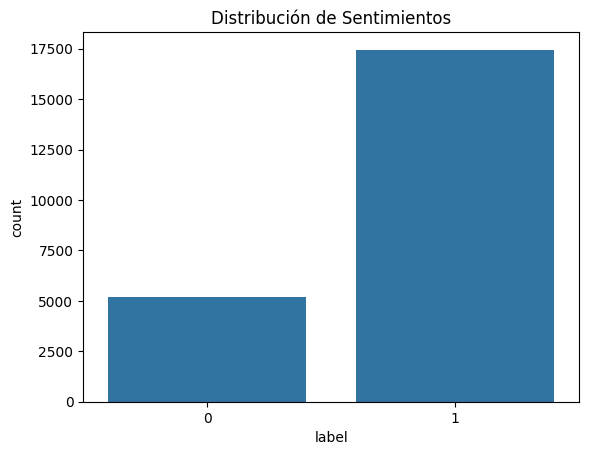

In [6]:
# Visualización para entender los datos
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="label")
plt.title("Distribución de Sentimientos")
plt.show()

In [7]:
df = df[["Review Text", "label"]]
df.head()

,Review Text,label
0,Absolutely wonderful - silky and sexy and comf...,1
1,Love this dress! it's sooo pretty. i happene...,1
2,I had such high hopes for this dress and reall...,0
3,"I love, love, love this jumpsuit. it's fun, fl...",1
4,This shirt is very flattering to all due to th...,1


In [8]:
!pip install transformers torch accelerate -q

In [9]:
import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from transformers import pipeline

In [11]:
# division de datos en entrenamiento y prueba
X = df["Review Text"].astype(str)
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [12]:
X_eval = X_test[:500].tolist()
y_eval = y_test[:500].tolist()

In [13]:
def evaluar_modelo(nombre_modelo, modelo_hf, tipo_salida="positive_negative"):

    print(f"Evaluando: {nombre_modelo}")

    clasificador = pipeline(
        "sentiment-analysis",
        model=modelo_hf,
        truncation=True
    )

    predicciones = []
    inicio = time.time()

    for texto in X_eval:
        resultado = clasificador(texto)[0]
        etiqueta = resultado["label"]

        if tipo_salida == "positive_negative":
            if etiqueta.upper() == "POSITIVE":
                predicciones.append(1)
            else:
                predicciones.append(0)

        elif tipo_salida == "stars":
            estrellas = int(etiqueta[0])

            if estrellas >= 4:
                predicciones.append(1)
            else:
                predicciones.append(0)

    fin = time.time()

    return {
        "Modelo": nombre_modelo,
        "Accuracy": round(accuracy_score(y_eval, predicciones), 4),
        "Precision": round(precision_score(y_eval, predicciones), 4),
        "Recall": round(recall_score(y_eval, predicciones), 4),
        "F1-score": round(f1_score(y_eval, predicciones), 4),
        "Tiempo_segundos": round(fin - inicio, 2)
    }

In [14]:
resultados = []

resultados.append(
    evaluar_modelo(
        "DistilBERT SST-2",
        "distilbert-base-uncased-finetuned-sst-2-english",
        "positive_negative"
    )
)

resultados.append(
    evaluar_modelo(
        "RoBERTa Twitter Sentiment",
        "cardiffnlp/twitter-roberta-base-sentiment-latest",
        "positive_negative"
    )
)

resultados.append(
    evaluar_modelo(
        "BERT Multilingual Stars",
        "nlptown/bert-base-multilingual-uncased-sentiment",
        "stars"
    )
)

Evaluando: DistilBERT SST-2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

...

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [15]:
tabla_resultados = pd.DataFrame(resultados)

tabla_resultados = tabla_resultados.sort_values(
    by="F1-score",
    ascending=False
)

tabla_resultados

,Modelo,Accuracy,Precision,Recall,F1-score,Tiempo_segundos
2,BERT Multilingual Stars,0.876,0.9645,0.8670,0.9132,187.99
0,DistilBERT SST-2,0.860,0.9158,0.8963,0.9059,118.59
1,RoBERTa Twitter Sentiment,0.840,0.8834,0.9069,0.8950,189.93


In [16]:
mejor_modelo = tabla_resultados.iloc[0]
mejor_modelo

,2
Modelo,BERT Multilingual Stars
Accuracy,0.876
Precision,0.9645
Recall,0.867
F1-score,0.9132
Tiempo_segundos,187.99


In [17]:
nombre_modelo_ganador = tabla_resultados.iloc[0]["Modelo"]

print(nombre_modelo_ganador)

BERT Multilingual Stars


In [18]:
modelo_final = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [19]:
nuevas_resenas = [
    "This dress is amazing and fits perfectly",
    "Terrible quality and very uncomfortable"
]

for texto in nuevas_resenas:
    resultado = modelo_final(texto)[0]
    estrellas = int(resultado["label"][0])

    sentimiento = 1 if estrellas >= 4 else 0
    etiqueta = "Positivo" if sentimiento == 1 else "Negativo"

    print("Texto:", texto)
    print("Predicción:", etiqueta)
    print("Estrellas:", resultado["label"])
    print("Confianza:", round(resultado["score"], 4))
    print()

Texto: This dress is amazing and fits perfectly
Predicción: Positivo
Estrellas: 5 stars
Confianza: 0.9116

Texto: Terrible quality and very uncomfortable
Predicción: Negativo
Estrellas: 1 star
Confianza: 0.8883

